In [1]:
#In this notebook, ,
#we will classify small images cifar10 dataset from tensorflow keras datasets.
import tensorflow as tf
from tensorflow.keras import datasets, layers , models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
#Load the dataset

(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 [==============================] - 615s 4us/step


(50000, 32, 32, 3)

In [3]:
X_test.shape


(10000, 32, 32, 3)

In [4]:
y_train.shape


(50000, 1)

In [5]:
y_train[:5] 
#y_train is a 2D array, for our classification having 1D array is good enough.
#so we will convert this to now 1D array

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [6]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [7]:
y_test = y_test.reshape(-1,)


In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


In [9]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

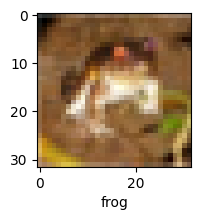

In [10]:
plot_sample(X_train, y_train, 0)


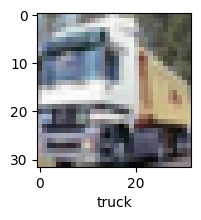

In [11]:
plot_sample(X_train, y_train, 1)


In [12]:
#Normalizing the training data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
#Build simple ANN for image classification
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 [==============================] - 67s 42ms/step - loss: 1.8170 - accuracy: 0.3520
Epoch 2/5
1563/1563 [==============================] - 83s 53ms/step - loss: 1.6254 - accuracy: 0.4262
Epoch 3/5
1563/1563 [==============================] - 83s 53ms/step - loss: 1.5408 - accuracy: 0.4565
Epoch 4/5
1563/1563 [==============================] - 87s 56ms/step - loss: 1.4813 - accuracy: 0.4776
Epoch 5/5
1563/1563 [==============================] - 77s 49ms/step - loss: 1.4346 - accuracy: 0.4957


In [14]:
#You can see that at the end of 5 epochs, accuracy is at around 49%
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 [==============================] - 5s 16ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.71      0.38      0.50      1000
           1       0.52      0.73      0.61      1000
           2       0.42      0.26      0.32      1000
           3       0.46      0.10      0.17      1000
           4       0.34      0.54      0.42      1000
           5       0.35      0.51      0.42      1000
           6       0.60      0.40      0.48      1000
           7       0.45      0.64      0.53      1000
           8       0.56      0.68      0.61      1000
           9       0.57      0.48      0.52      1000

    accuracy                           0.47     10000
   macro avg       0.50      0.47      0.46     10000
weighted avg       0.50      0.47      0.46     10000



In [15]:
# Now let us build a convolutional neural network to train our images

cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [16]:

cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=10)



Epoch 1/10
1563/1563 [==============================] - 41s 26ms/step - loss: 1.4643 - accuracy: 0.4721
Epoch 2/10
1563/1563 [==============================] - 38s 24ms/step - loss: 1.1124 - accuracy: 0.6117
Epoch 3/10
1563/1563 [==============================] - 41s 26ms/step - loss: 0.9764 - accuracy: 0.6591
Epoch 4/10
1563/1563 [==============================] - 38s 25ms/step - loss: 0.8894 - accuracy: 0.6912
Epoch 5/10
1563/1563 [==============================] - 36s 23ms/step - loss: 0.8304 - accuracy: 0.7129
Epoch 6/10
1563/1563 [==============================] - 36s 23ms/step - loss: 0.7708 - accuracy: 0.7324
Epoch 7/10
1563/1563 [==============================] - 36s 23ms/step - loss: 0.7250 - accuracy: 0.7489
Epoch 8/10
1563/1563 [==============================] - 37s 23ms/step - loss: 0.6853 - accuracy: 0.7621
Epoch 9/10
1563/1563 [==============================] - 37s 23ms/step - loss: 0.6409 - accuracy: 0.7754
Epoch 10/10
1563/1563 [==============================] - 37s 23m

In [17]:
#With CNN, at the end 5 epochs, accuracy was at around 70%
#which is a significant improvement over ANN. 
#CNN's are best for image classification and gives superb accuracy. 
#Also computation is much less compared to simple ANN as maxpooling 
#reduces the image dimensions while still preserving the features
cnn.evaluate(X_test,y_test)

313/313 [==============================] - 4s 11ms/step - loss: 0.9383 - accuracy: 0.6890


[0.9383289813995361, 0.6890000104904175]

In [18]:

y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 [==============================] - 3s 9ms/step


array([[7.5487979e-04, 3.1224408e-04, 9.5932400e-03, 9.6314669e-01,
        3.2629489e-04, 6.6169021e-03, 4.3743919e-03, 4.4771623e-06,
        1.4868961e-02, 1.8816947e-06],
       [2.7658003e-03, 3.8611034e-03, 1.3135025e-05, 7.8740777e-06,
        5.3411650e-08, 1.5987902e-06, 4.7822223e-08, 3.4582577e-08,
        9.9281090e-01, 5.3950521e-04],
       [2.2352612e-02, 2.2194642e-01, 3.1041820e-03, 3.2978726e-03,
        9.8983594e-04, 8.0113730e-04, 3.7941974e-04, 4.7484651e-04,
        7.4139291e-01, 5.2608186e-03],
       [2.4604346e-01, 5.5945846e-03, 2.6301103e-02, 2.6867748e-03,
        6.8451103e-05, 2.6100215e-05, 4.0858198e-04, 1.8847550e-05,
        7.1865153e-01, 2.0051589e-04],
       [5.6254703e-05, 3.4819586e-05, 1.9028482e-01, 7.2814569e-02,
        7.9606473e-02, 5.4614949e-03, 6.5141201e-01, 2.1346207e-06,
        3.2745476e-04, 4.9830177e-08]], dtype=float32)

In [19]:

y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 8, 6]

In [20]:
y_test[:5]


array([3, 8, 8, 0, 6], dtype=uint8)

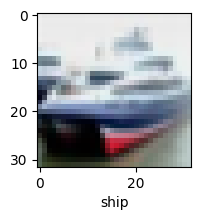

In [23]:
plot_sample(X_test, y_test,1)


In [24]:
classes[y_classes[3]]


'ship'

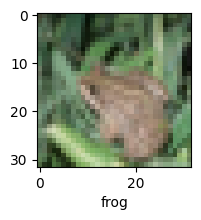

In [37]:
plot_sample(X_test, y_test,4)


In [36]:
classes[y_classes[4]]


'frog'